In [37]:
# Importing standard libraries

import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import cm
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
sns.set(style="darkgrid",font_scale=1.5)


from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_val_score,cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


ORANGE  = '#FF5722'
AMBER   = '#FFC107'
TEAL  = '#009688'
PURPLE='#9C27B0'
GREY  = '#9E9E9E'



In [38]:
customer_data= pd.read_csv("/Users/matet/Desktop/AIM AI Machine Learning/Projects/Capstone Project/bank customer/Churn_customer.csv")

customer_data.head

<bound method NDFrame.head of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfPro

In [39]:
customer_data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [40]:
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [41]:
customer_data[customer_data.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [42]:
customer_data.describe(include="object").T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


In [43]:
# customer_id is a pure identifier — no predictive value, remove it
customer_data.drop(columns=['CustomerId'], inplace=True)
customer_data.drop(columns=['RowNumber'], inplace=True)
print(f"Columns remaining: {list(customer_data.columns)}")

Columns remaining: ['Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


# EXLORATORY DATA ANALYSIS

##### 1.1 TOTAL OVERALL CHURN RATE

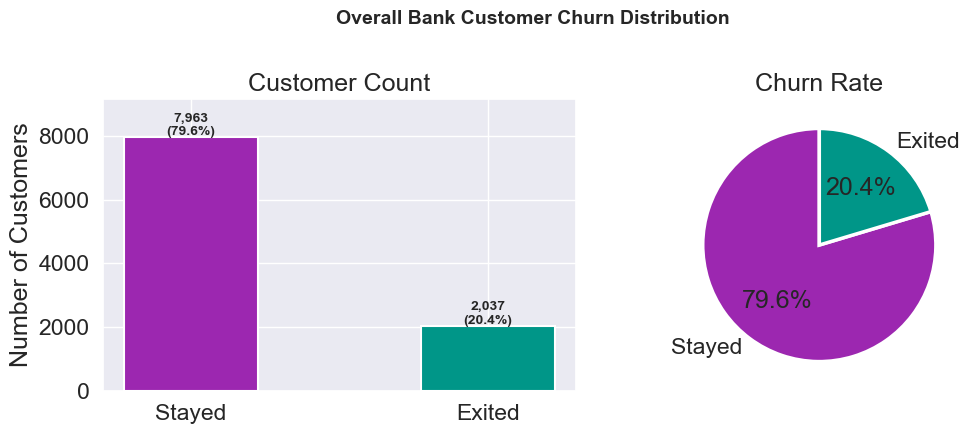

Exited:2,037 customers (20.4%)
Stayed:7,963 customers (79.6%)


In [44]:
# SUMMARY OF EXITED CUSTOMER

churn_counts = customer_data["Exited"].value_counts()
churn_percentages = customer_data["Exited"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Overall Bank Customer Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(
    ['Stayed', 'Exited'], churn_counts.values,
    color=[PURPLE, TEAL], edgecolor='white', linewidth=1.5, width=0.45
)
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Count')
axes[0].set_ylim(0, churn_counts.max() * 1.15)
for bar, churn, pct in zip(bars, churn_counts.values, churn_percentages.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f'{churn:,}\n({pct:.1f}%)',
        ha='center', fontweight='bold', fontsize=10
    )

# Pie chart
axes[1].pie(
    customer_data["Exited"].value_counts().values,
    labels=['Stayed', 'Exited'],
    autopct='%1.1f%%',
    colors=[PURPLE, TEAL],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}
)
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.savefig('plot_01_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"Exited:{churn_counts[1]:,} customers ({churn_percentages[1]:.1f}%)")
print(f"Stayed:{churn_counts[0]:,} customers ({churn_percentages[0]:.1f}%)")


## 1.2 OVERALL CHURN RATE by AGE

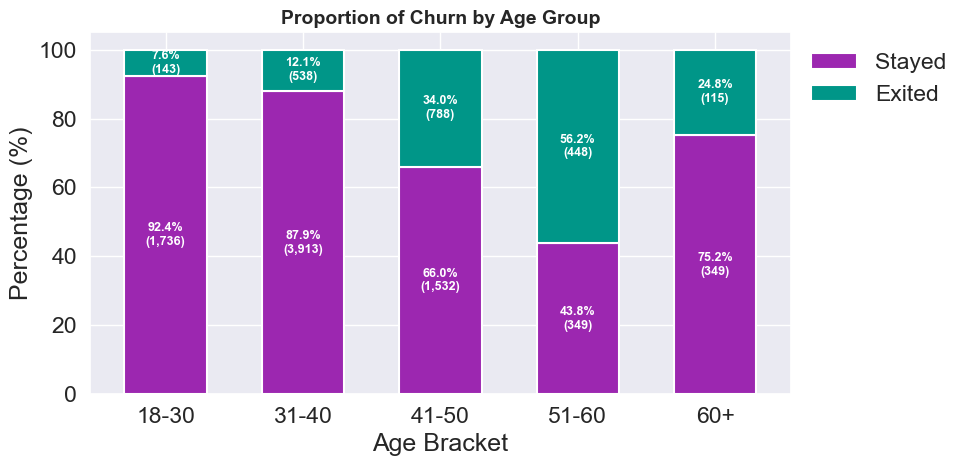

age_bracket  total  churned  churn_rate_pct
      18-30   1879      143             7.6
      31-40   4451      538            12.1
      41-50   2320      788            34.0
      51-60    797      448            56.2
        60+    464      115            24.8


In [45]:

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Bin the data
customer_data["age_bracket"] = pd.cut(
    customer_data["Age"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"],
)

# 2. Get normalized cross-tabulation (percentages) for plotting
age_crosstab = (
    pd.crosstab(
        customer_data["age_bracket"], customer_data["Exited"], normalize="index"
    )
    * 100
)

# NEW: Get raw counts for the annotations
age_counts = pd.crosstab(customer_data["age_bracket"], customer_data["Exited"])

# 3. Plot stacked bars
age_crosstab.plot(
    kind="bar",
    stacked=True,
    color=[PURPLE, TEAL],
    width=0.6,
    ax=ax,
    edgecolor="white",
    linewidth=1.5,
)

ax.set_title(
    "Proportion of Churn by Age Group", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Age Bracket")
ax.set_ylabel("Percentage (%)")
ax.legend(
    ["Stayed", "Exited"], frameon=False, loc="upper left", bbox_to_anchor=(1, 1)
)

# Add the percentage and count text annotations inside the bars
for i in range(len(age_crosstab)):
    # Stayed label
    stayed_pct = age_crosstab.iloc[i, 0]
    stayed_count = age_counts.iloc[i, 0]
    ax.text(
        i,
        stayed_pct / 2,
        f"{stayed_pct:.1f}%\n({stayed_count:,})",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=9,
    )

    # Exited label
    exited_pct = age_crosstab.iloc[i, 1]
    exited_count = age_counts.iloc[i, 1]
    ax.text(
        i,
        stayed_pct + (exited_pct / 2),
        f"{exited_pct:.1f}%\n({exited_count:,})",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=9,
    )

plt.xticks(rotation=0)

# Calculate age stats for the printout before dropping the column
age_stats = (
    customer_data.groupby("age_bracket", observed=True)
    .agg(
        total=("Exited", "count"),
        churned=("Exited", "sum"),
        churn_rate_pct=("Exited", lambda x: x.mean() * 100),
    )
    .reset_index()
)

customer_data.drop(columns=["age_bracket"], inplace=True)  # clean up

plt.tight_layout()
plt.savefig("plot_03_churn_age_stacked.png", bbox_inches="tight")
plt.show()

# Print summary table
print(
    age_stats[["age_bracket", "total", "churned", "churn_rate_pct"]]
    .round(1)
    .to_string(index=False)
)

### 1.3 Total Churn by Tenure

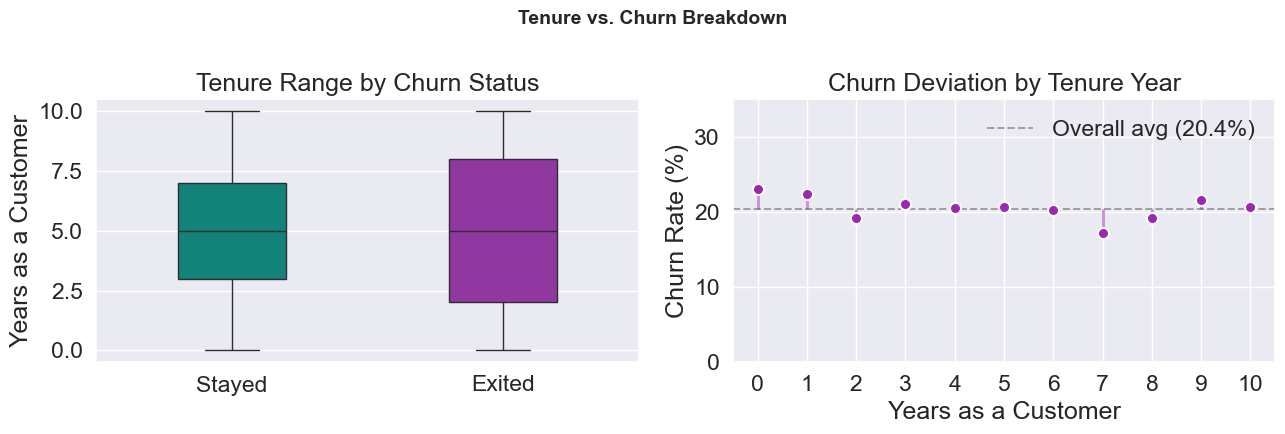

Correlation between tenure and churn: -0.0140
Average tenure — stayed:  5.03 years
Average tenure — churned: 4.93 years


In [46]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Tenure vs. Churn Breakdown", fontsize=14, fontweight="bold")

# Calculate averages
avg_t_stayed = customer_data[customer_data["Exited"] == 0]["Tenure"].mean()
avg_t_churned = customer_data[customer_data["Exited"] == 1]["Tenure"].mean()
tenure_rate = customer_data.groupby("Tenure")["Exited"].mean() * 100
avg = customer_data["Exited"].mean() * 100

# 1. Boxplot
sns.boxplot(
    data=customer_data, x="Exited", y="Tenure", palette=[TEAL, PURPLE], width=0.4, ax=axes[0]
)
axes[0].set_title("Tenure Range by Churn Status")
axes[0].set_xticklabels(["Stayed", "Exited"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Years as a Customer")

# 2. Lollipop Chart (Stems pointing to the churn rates)
axes[1].axhline(
    avg,
    color=GREY,
    linestyle="--",
    linewidth=1.4,
    label=f"Overall avg ({avg:.1f}%)",
)

# Draw the 'stems' from the average line to the points
axes[1].vlines(
    x=tenure_rate.index,
    ymin=avg,
    ymax=tenure_rate.values,
    color=PURPLE,
    alpha=0.5,
    linewidth=2,
)
#Draw the lollipops
axes[1].plot(
    tenure_rate.index,
    tenure_rate.values,
    "o",
    color=PURPLE,
    markersize=8,
    markeredgecolor="white",
    markeredgewidth=1.5,
    linewidth=0,
)

axes[1].set_xlabel("Years as a Customer")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_title("Churn Deviation by Tenure Year")
axes[1].set_xticks(range(0, 11))
axes[1].set_ylim(0, 35)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("plot_04_churn_tenure_v2.png", bbox_inches="tight")
plt.show()

# Print statements
tenure_corr = customer_data["Tenure"].corr(customer_data["Exited"])
print(f"Correlation between tenure and churn: {tenure_corr:.4f}")
print(f"Average tenure — stayed:  {avg_t_stayed:.2f} years")
print(f"Average tenure — churned: {avg_t_churned:.2f} years")

"customer churn isn't triggered by how long someone has been with us; loyal and new accounts leave at roughly the exact same clip. However, we have a minor retention issue in a customer's first 12 to 24 months. If successfully push past that initial window and get them closer to the 7-year mark where loyalty peaks, our overall churn rate will drop."

### 1.5 Engagement and Products

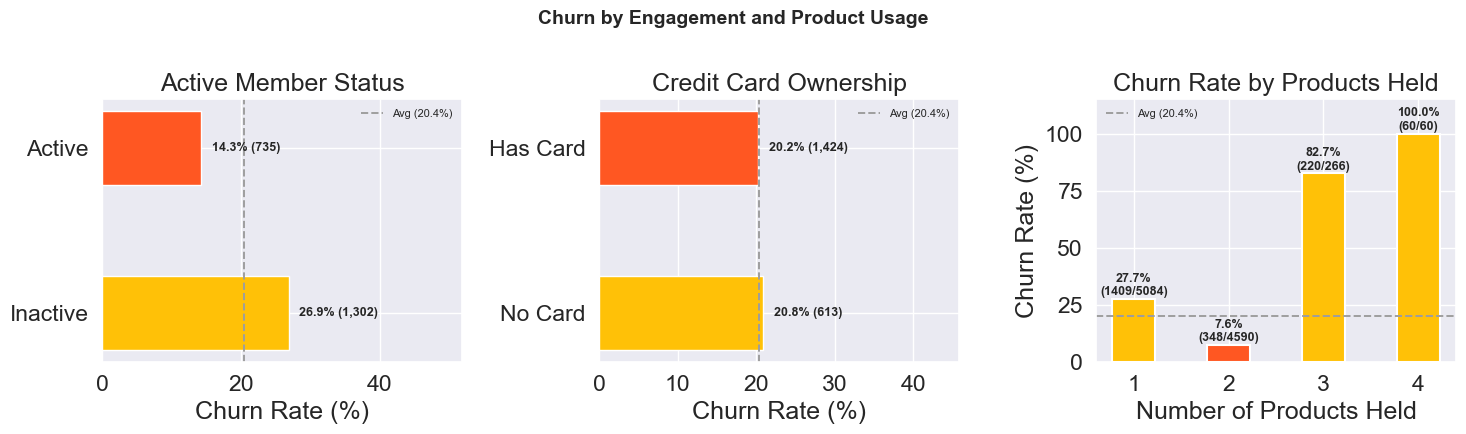

Churn rate by active member:
IsActiveMember
0    26.9
1    14.3
Name: Exited, dtype: float64

Churn rate by products:
NumOfProducts
1     27.7
2      7.6
3     82.7
4    100.0
Name: Exited, dtype: float64


In [47]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    "Churn by Engagement and Product Usage", fontsize=14, fontweight="bold"
)

avg = customer_data["Exited"].mean() * 100


# Helper to avoid massive repetitive code
def horizontal_churn(ax, rates_data, counts_data, title, custom_labels=None):
    rates = rates_data * 100
    counts = counts_data
    colors = [AMBER if r > avg else ORANGE for r in rates.values]
    labels = (
        custom_labels if custom_labels else rates.index.astype(str).tolist()
    )

    bars = ax.barh(
        labels, rates.values, color=colors, height=0.45, edgecolor="white"
    )

    ax.axvline(
        avg, color=GREY, linestyle="--", linewidth=1.4, label=f"Avg ({avg:.1f}%)"
    )
    ax.set_title(title)
    ax.set_xlabel("Churn Rate (%)")
    ax.set_xlim(0, max(rates.values) + 25 if max(rates.values) < 80 else 125)
    ax.legend(frameon=False, fontsize=8)

    for bar, r, c in zip(bars, rates.values, counts.values):
        ax.text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{r:.1f}% ({c:,})",
            ha="left",
            va="center",
            fontweight="bold",
            fontsize=9,
        )


# Plot first two horizontally
horizontal_churn(
    axes[0],
    customer_data.groupby("IsActiveMember")["Exited"].mean(),
    customer_data.groupby("IsActiveMember")["Exited"].sum(),
    "Active Member Status",
    ["Inactive", "Active"],
)

horizontal_churn(
    axes[1],
    customer_data.groupby("HasCrCard")["Exited"].mean(),
    customer_data.groupby("HasCrCard")["Exited"].sum(),
    "Credit Card Ownership",
    ["No Card", "Has Card"],
)

# 3. Third chart remains a vertical bar chart to create dynamic contrast in the grid!
prod_churn = customer_data.groupby("NumOfProducts")["Exited"].mean() * 100
prod_counts = customer_data.groupby("NumOfProducts")["Exited"].sum()
prod_total = customer_data.groupby("NumOfProducts")["Exited"].count()
p_colors = [AMBER if r > avg else ORANGE for r in prod_churn.values]

bars3 = axes[2].bar(
    prod_churn.index.astype(str),
    prod_churn.values,
    color=p_colors,
    width=0.45,
    edgecolor="white",
    linewidth=1.5,
)
axes[2].axhline(
    avg, color=GREY, linestyle="--", linewidth=1.4, label=f"Avg ({avg:.1f}%)"
)
axes[2].set_xlabel("Number of Products Held")
axes[2].set_ylabel("Churn Rate (%)")
axes[2].set_title("Churn Rate by Products Held")
axes[2].set_ylim(0, 115)
axes[2].legend(frameon=False, fontsize=8)

for bar, r, c, t in zip(
    bars3, prod_churn.values, prod_counts.values, prod_total.values
):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{r:.1f}%\n({c}/{t})",
        ha="center",
        fontweight="bold",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("plot_05_churn_horizontal.png", bbox_inches="tight")
plt.show()

# Print statements using the correct column names
print("Churn rate by active member:")
print((customer_data.groupby("IsActiveMember")["Exited"].mean() * 100).round(1))
print("\nChurn rate by products:")
print(prod_churn.round(1))

### FEATURE ENGINEERING

In [48]:

# -------------------------------------------------------------------------
# 1. Product & Balance Interaction Features
# -------------------------------------------------------------------------
# Balance Per Product
customer_data["Balance_Per_Product"] = (
    customer_data["Balance"] / customer_data["NumOfProducts"]
)

# Is High-Value Zero-Product User (Flags single-product users with above-median balance)
median_balance = customer_data["Balance"].median()
customer_data["Is_HighValue_SingleProduct"] = (
    (customer_data["Balance"] > median_balance)
    & (customer_data["NumOfProducts"] == 1)
).astype(int)


# -------------------------------------------------------------------------
# 2. Customer Lifecycle & Age Features
# -------------------------------------------------------------------------
# Tenure-to-Age Ratio
customer_data["Tenure_Age_Ratio"] = (
    customer_data["Tenure"] / customer_data["Age"]
)


# Life Stage Categorization
def get_life_stage(age):
    if age <= 25:
        return "Young Adult"
    elif age <= 40:
        return "Career Builder"
    elif age <= 60:
        return "Mid-Life"
    else:
        return "Retired"


customer_data["Life_Stage"] = customer_data["Age"].apply(get_life_stage)


# -------------------------------------------------------------------------
# 3. Financial Health & Salary Ratios
# -------------------------------------------------------------------------
# Balance-to-Salary Ratio
customer_data["Balance_Salary_Ratio"] = (
    customer_data["Balance"] / customer_data["EstimatedSalary"]
)

# Estimated Monthly Discretionary Income (Simplified)
customer_data["Est_Monthly_Income"] = customer_data["EstimatedSalary"] / 12


# -------------------------------------------------------------------------
# 4. Engagement Personas (The "Golden" Feature)
# -------------------------------------------------------------------------
def get_loyalty_persona(row):
    active = row["IsActiveMember"]
    products = row["NumOfProducts"]

    if active == 1 and products == 2:
        return "Ideal Customer"
    elif active == 0 and products == 1:
        return "Disengaged Rookie"
    elif active == 1 and products >= 3:
        return "Overwhelmed VIP"
    elif active == 0 and products >= 3:
        return "Critically At Risk"
    else:
        return "Standard Account"


customer_data["Customer_Persona"] = customer_data.apply(
    get_loyalty_persona, axis=1
)


# -------------------------------------------------------------------------
# 5. Data Cleanup (Crucial for Machine Learning)
# -------------------------------------------------------------------------
# Replacing any potential division-by-zero infinities with 0
customer_data.replace([np.inf, -np.inf], 0, inplace=True)
customer_data.fillna(0, inplace=True)

print("Feature engineering complete!")
print(
    f"New columns added: {['Balance_Per_Product', 'Is_HighValue_SingleProduct', 'Tenure_Age_Ratio', 'Life_Stage', 'Balance_Salary_Ratio', 'Est_Monthly_Income', 'Customer_Persona']}"
)

Feature engineering complete!
New columns added: ['Balance_Per_Product', 'Is_HighValue_SingleProduct', 'Tenure_Age_Ratio', 'Life_Stage', 'Balance_Salary_Ratio', 'Est_Monthly_Income', 'Customer_Persona']


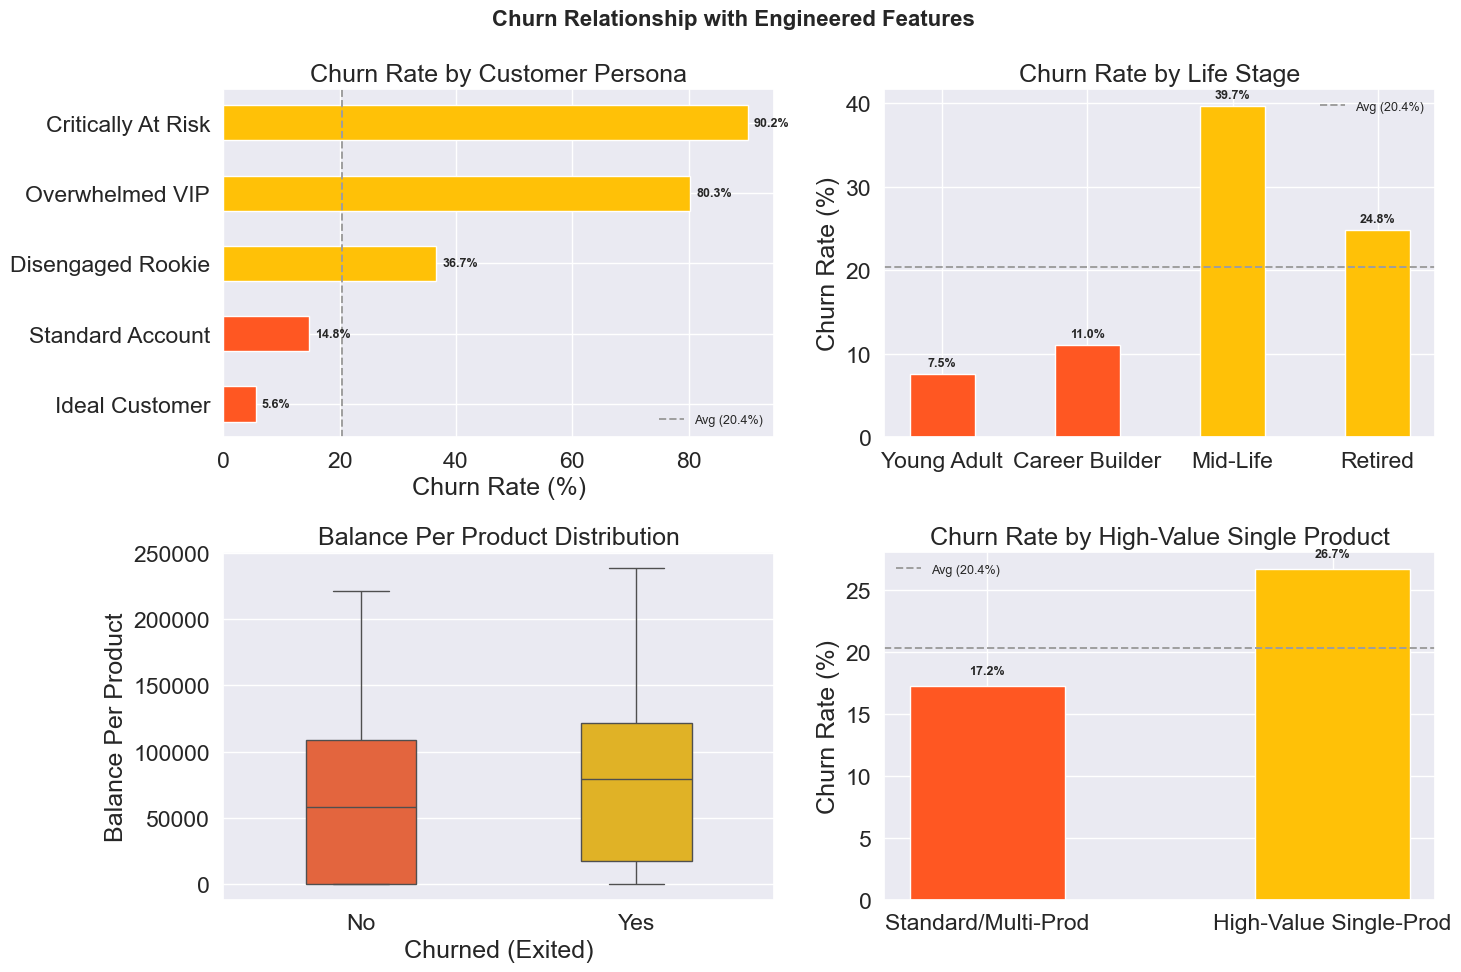

In [49]:


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    "Churn Relationship with Engineered Features",
    fontsize=16,
    fontweight="bold",
)

# Baseline average churn rate
avg_churn = customer_data["Exited"].mean() * 100

# -------------------------------------------------------------------------
# 1. Churn Rate by Customer Persona (Categorical)
# -------------------------------------------------------------------------
persona_rates = (
    customer_data.groupby("Customer_Persona")["Exited"].mean().sort_values()
    * 100
)
colors1 = [AMBER if r > avg_churn else ORANGE for r in persona_rates.values]

bars1 = axes[0, 0].barh(
    persona_rates.index,
    persona_rates.values,
    color=colors1,
    height=0.5,
    edgecolor="white",
)
axes[0, 0].axvline(
    avg_churn,
    color=GREY,
    linestyle="--",
    linewidth=1.4,
    label=f"Avg ({avg_churn:.1f}%)",
)
axes[0, 0].set_title("Churn Rate by Customer Persona")
axes[0, 0].set_xlabel("Churn Rate (%)")
axes[0, 0].legend(frameon=False, fontsize=9)

for bar, r in zip(bars1, persona_rates.values):
    axes[0, 0].text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{r:.1f}%",
        va="center",
        fontweight="bold",
        fontsize=9,
    )

# -------------------------------------------------------------------------
# 2. Churn Rate by Life Stage (Categorical)
# -------------------------------------------------------------------------
life_order = ["Young Adult", "Career Builder", "Mid-Life", "Retired"]
life_rates = (
    customer_data.groupby("Life_Stage")["Exited"].mean().reindex(life_order)
    * 100
)
colors2 = [AMBER if r > avg_churn else ORANGE for r in life_rates.values]

bars2 = axes[0, 1].bar(
    life_rates.index,
    life_rates.values,
    color=colors2,
    width=0.45,
    edgecolor="white",
)
axes[0, 1].axhline(
    avg_churn,
    color=GREY,
    linestyle="--",
    linewidth=1.4,
    label=f"Avg ({avg_churn:.1f}%)",
)
axes[0, 1].set_title("Churn Rate by Life Stage")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].legend(frameon=False, fontsize=9)

for bar, r in zip(bars2, life_rates.values):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{r:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=9,
    )

# -------------------------------------------------------------------------
# 3. Balance Per Product by Churn (Continuous - Boxplot)
# -------------------------------------------------------------------------
sns.boxplot(
    ax=axes[1, 0],
    x="Exited",
    y="Balance_Per_Product",
    data=customer_data,
    palette=[ORANGE, AMBER],
    width=0.4,
)
axes[1, 0].set_title("Balance Per Product Distribution")
axes[1, 0].set_xlabel("Churned (Exited)")
axes[1, 0].set_ylabel("Balance Per Product")
axes[1, 0].set_xticklabels(["No", "Yes"])

# -------------------------------------------------------------------------
# 4. Churn Rate by Is_HighValue_SingleProduct (Binary)
# -------------------------------------------------------------------------
hv_rates = (
    customer_data.groupby("Is_HighValue_SingleProduct")["Exited"].mean() * 100
)
colors4 = [AMBER if r > avg_churn else ORANGE for r in hv_rates.values]

bars4 = axes[1, 1].bar(
    ["Standard/Multi-Prod", "High-Value Single-Prod"],
    hv_rates.values,
    color=colors4,
    width=0.45,
    edgecolor="white",
)
axes[1, 1].axhline(
    avg_churn,
    color=GREY,
    linestyle="--",
    linewidth=1.4,
    label=f"Avg ({avg_churn:.1f}%)",
)
axes[1, 1].set_title("Churn Rate by High-Value Single Product")
axes[1, 1].set_ylabel("Churn Rate (%)")
axes[1, 1].legend(frameon=False, fontsize=9)

for bar, r in zip(bars4, hv_rates.values):
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{r:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("plot_06_engineered_features.png", bbox_inches="tight")
plt.show()

## CORRELATION

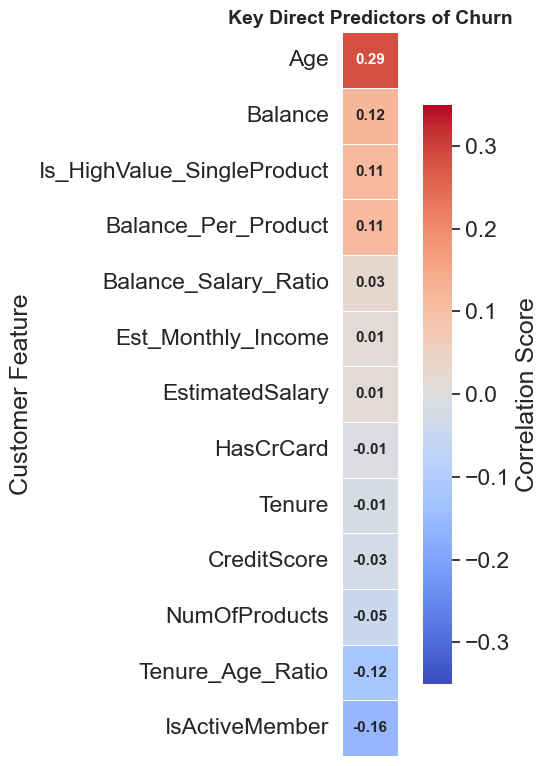

In [50]:

# 1. Define all numeric and engineered columns
numerical_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Balance_Per_Product",
    "Is_HighValue_SingleProduct",
    "Tenure_Age_Ratio",
    "Balance_Salary_Ratio",
    "Est_Monthly_Income",
]

# 2. Safety check: Grab only the columns that actually exist in your DataFrame
existing_cols = [col for col in numerical_cols if col in customer_data.columns]

# 3. Calculate the full correlation matrix including 'Exited'
full_corr_matrix = customer_data[existing_cols + ["Exited"]].corr()

# -------------------------------------------------------------------------
# 🚀 THE OPTIMIZATION: Focused Heatmap for Churn Direct Predictors
# -------------------------------------------------------------------------
# Isolate just the 'Exited' column and drop the redundant diagonal self-correlation
churn_corr = (
    full_corr_matrix["Exited"]
    .drop("Exited")
    .sort_values(ascending=False)
    .to_frame()
)

# Set up the smaller, focused figure size (tall and thin)
fig, ax = plt.subplots(figsize=(6, 8))

sns.heatmap(
    churn_corr,
    annot=True,  # Red = Positive Correlation, Blue = Negative Correlation
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.35,  # Focus the color scale on the realistic range of correlations
    vmax=0.35,
    square=True,
    linewidths=0.7,
    annot_kws={"size": 11, "fontweight": "bold"},
    cbar_kws={"shrink": 0.8, "label": "Correlation Score"},
    ax=ax,
)

ax.set_title(
    "Key Direct Predictors of Churn", fontsize=14, fontweight="bold"
)
ax.set_xticklabels([])  # Hide redundant label
ax.set_ylabel("Customer Feature")
plt.tight_layout()

# Save the focused heatmap
plt.savefig("plot_08_churn_heatmap.png", bbox_inches="tight")

## 3. Preprocessing

In [51]:
customer_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Surname                     10000 non-null  str    
 1   CreditScore                 10000 non-null  int64  
 2   Geography                   10000 non-null  str    
 3   Gender                      10000 non-null  str    
 4   Age                         10000 non-null  int64  
 5   Tenure                      10000 non-null  int64  
 6   Balance                     10000 non-null  float64
 7   NumOfProducts               10000 non-null  int64  
 8   HasCrCard                   10000 non-null  int64  
 9   IsActiveMember              10000 non-null  int64  
 10  EstimatedSalary             10000 non-null  float64
 11  Exited                      10000 non-null  int64  
 12  Balance_Per_Product         10000 non-null  float64
 13  Is_HighValue_SingleProduct  10000 non-null 

In [52]:
# =========================================
# STEP 1: Data Preparation
# =========================================



X = customer_data.drop(columns=['Exited'])
y = customer_data['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
# ============================================================
# STEP 2: Preprocessing Scaling (Handles Encoding and Scaling)
# ============================================================



# Identify columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [54]:
# ============================================================
# STEP 3: Define Models
# ============================================================



# Class imbalance ratio
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=neg_pos_ratio,
        random_state=42,
        n_jobs=-1
    )
}

In [55]:

# ============================================================
# STEP 4: Pipelines (Preprocessing + Model)
# ============================================================



pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

In [56]:

# ============================================================
# STEP 5: Cross Validation (Stratified K-Fold)
# ============================================================


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, pipeline in pipelines.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name} CV AUC: {np.mean(scores):.4f}")

Logistic Regression CV AUC: 0.8386
Random Forest CV AUC: 0.8341
XGBoost CV AUC: 0.8472


In [57]:
# ============================================================
# STEP 5A: Cross Validation (Stratified K-Fold)
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring={
            'roc_auc': 'roc_auc',
            'recall': 'recall',
            'precision': 'precision'
        },
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "ROC-AUC": scores['test_roc_auc'].mean(),
        "Recall": scores['test_recall'].mean(),
        "Precision": scores['test_precision'].mean()
    })

cv_results_df = pd.DataFrame(results)
print(cv_results_df)

                 Model   ROC-AUC    Recall  Precision
0  Logistic Regression  0.838593  0.428834   0.690528
1        Random Forest  0.834109  0.710429   0.477311
2              XGBoost  0.847196  0.678528   0.537507


In [58]:

# ============================================================
# STEP 6A: Hyperparameter Tuning- XGBoost for fast computing
# ============================================================


xgb_pipeline = pipelines["XGBoost"]

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=skf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best CV AUC:", search.best_score_)
print("Best Params:", search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV AUC: 0.8636666795080468
Best Params: {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


In [59]:


# ============================================================
# STEP 6B: Hyperparameter Tuning- Logistic Regression
# ============================================================


log_pipeline = pipelines["Logistic Regression"]

log_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],     # regularization strength
    'model__penalty': ['l2'],               # keep stable
    'model__solver': ['lbfgs']              # compatible solver
}

log_search = RandomizedSearchCV(
    log_pipeline,
    param_distributions=log_param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=-1
)

log_search.fit(X_train, y_train)

best_log_model = log_search.best_estimator_

print("Best Logistic AUC:", log_search.best_score_)
print("Best Logistic Params:", log_search.best_params_)


Best Logistic AUC: 0.8444660072618004
Best Logistic Params: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 0.1}


In [60]:


# ============================================================
# STEP 6C: Hyperparameter Tuning- Random Forest
# ============================================================


rf_pipeline = pipelines["Random Forest"]

rf_param_grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_

print("Best RF AUC:", rf_search.best_score_)
print("Best RF Params:", rf_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF AUC: 0.8490715682214368
Best RF Params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}


In [61]:


# ============================================================
# STEP 7 — Final Evaluation on Test Set
# ============================================================

final_models = {
    "Logistic Regression": best_log_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_model   # optional
}

for name, model in final_models.items():
    print(f"\n=== {name} ===")
    
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Optional: custom threshold
    threshold = 0.3
    y_pred = (y_proba >= threshold).astype(int)
    
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))



=== Logistic Regression ===
ROC-AUC: 0.8546929055403633
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.56      0.65      0.60       407

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.84      0.82      0.83      2000


=== Random Forest ===
ROC-AUC: 0.8566625176794669
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      1593
           1       0.49      0.74      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.77      0.72      2000
weighted avg       0.83      0.79      0.80      2000


=== XGBoost ===
ROC-AUC: 0.8685156651258346
              precision    recall  f1-score   support

           0       0.95      0.60      0.74      1593
           1       0.36      0.89      0.51       407

    accuracy                 

In [62]:
# ============================================================
# STEP 7 — Final Evaluation on Test Set best model
# ============================================================


y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Test ROC-AUC: 0.8685156651258346
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1593
           1       0.51      0.78      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.80      0.81      2000



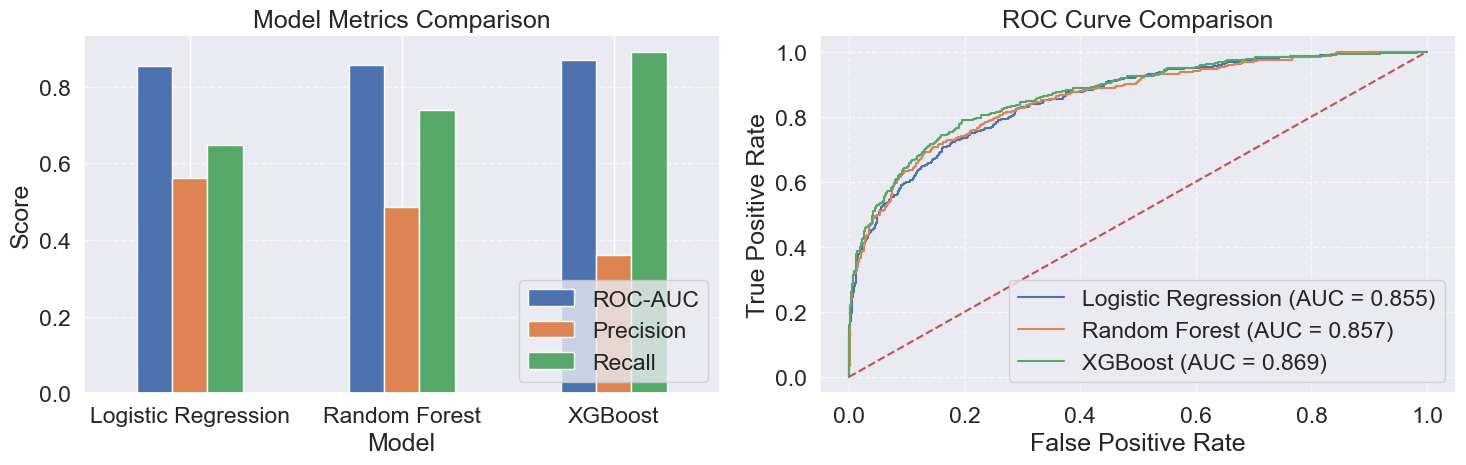

In [63]:

# ==========================================
# Final models to compare
# ==========================================
final_models = {
    "Logistic Regression": best_log_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_model   # or best_xgb_model if you renamed it
}

# ==========================================
# Compute test metrics
# ==========================================
results = []

for name, model in final_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.3).astype(int)   # optional custom threshold

    results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

# ==========================================
# Create one figure with two plots
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --------------------------
# Plot 1: Metrics Comparison
# --------------------------
metrics_df = results_df.set_index("Model")[["ROC-AUC", "Precision", "Recall"]]
metrics_df.plot(kind="bar", ax=axes[0])

axes[0].set_title("Model Metrics Comparison")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("Model")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# --------------------------
# Plot 2: ROC Curve
# --------------------------
for name, model in final_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title("ROC Curve Comparison")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [64]:

# ==========================================
# Final tuned models
# ==========================================
final_models = {
    "Logistic Regression": best_log_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_model   # or best_xgb_model if renamed
}

# ==========================================
# Get transformed feature names from preprocessor
# ==========================================
# Use any fitted pipeline, since all use the same preprocessor structure
sample_pipeline = list(final_models.values())[0]
preprocessor_fitted = sample_pipeline.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

# ==========================================
# Extract feature importance per model
# ==========================================
feature_importance_dict = {}

for model_name, pipeline in final_models.items():
    model = pipeline.named_steps["model"]
    
    if model_name == "Logistic Regression":
        # absolute coefficient magnitude for comparison
        importance = np.abs(model.coef_[0])
        
    elif model_name in ["Random Forest", "XGBoost"]:
        importance = model.feature_importances_
        
    else:
        continue
    
    feature_importance_dict[model_name] = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

# ==========================================
# Show top 10 features for each model
# ==========================================
for model_name, df in feature_importance_dict.items():
    print(f"\n=== Top 10 Features: {model_name} ===")
    print(df.head(10))


=== Top 10 Features: Logistic Regression ===
                                       Feature  Importance
2644      cat__Customer_Persona_Ideal Customer    2.612857
2642  cat__Customer_Persona_Critically At Risk    1.712955
2643   cat__Customer_Persona_Disengaged Rookie    1.061866
2646    cat__Customer_Persona_Standard Account    0.943765
8                     num__Balance_Per_Product    0.873022
2640                   cat__Life_Stage_Retired    0.847371
2645     cat__Customer_Persona_Overwhelmed VIP    0.725815
3                                 num__Balance    0.719175
2639                  cat__Life_Stage_Mid-Life    0.681286
1                                     num__Age    0.673236

=== Top 10 Features: Random Forest ===
                        Feature  Importance
1                      num__Age    0.080874
10        num__Tenure_Age_Ratio    0.045056
8      num__Balance_Per_Product    0.040967
0              num__CreditScore    0.039211
7          num__EstimatedSalary    0.038846
4

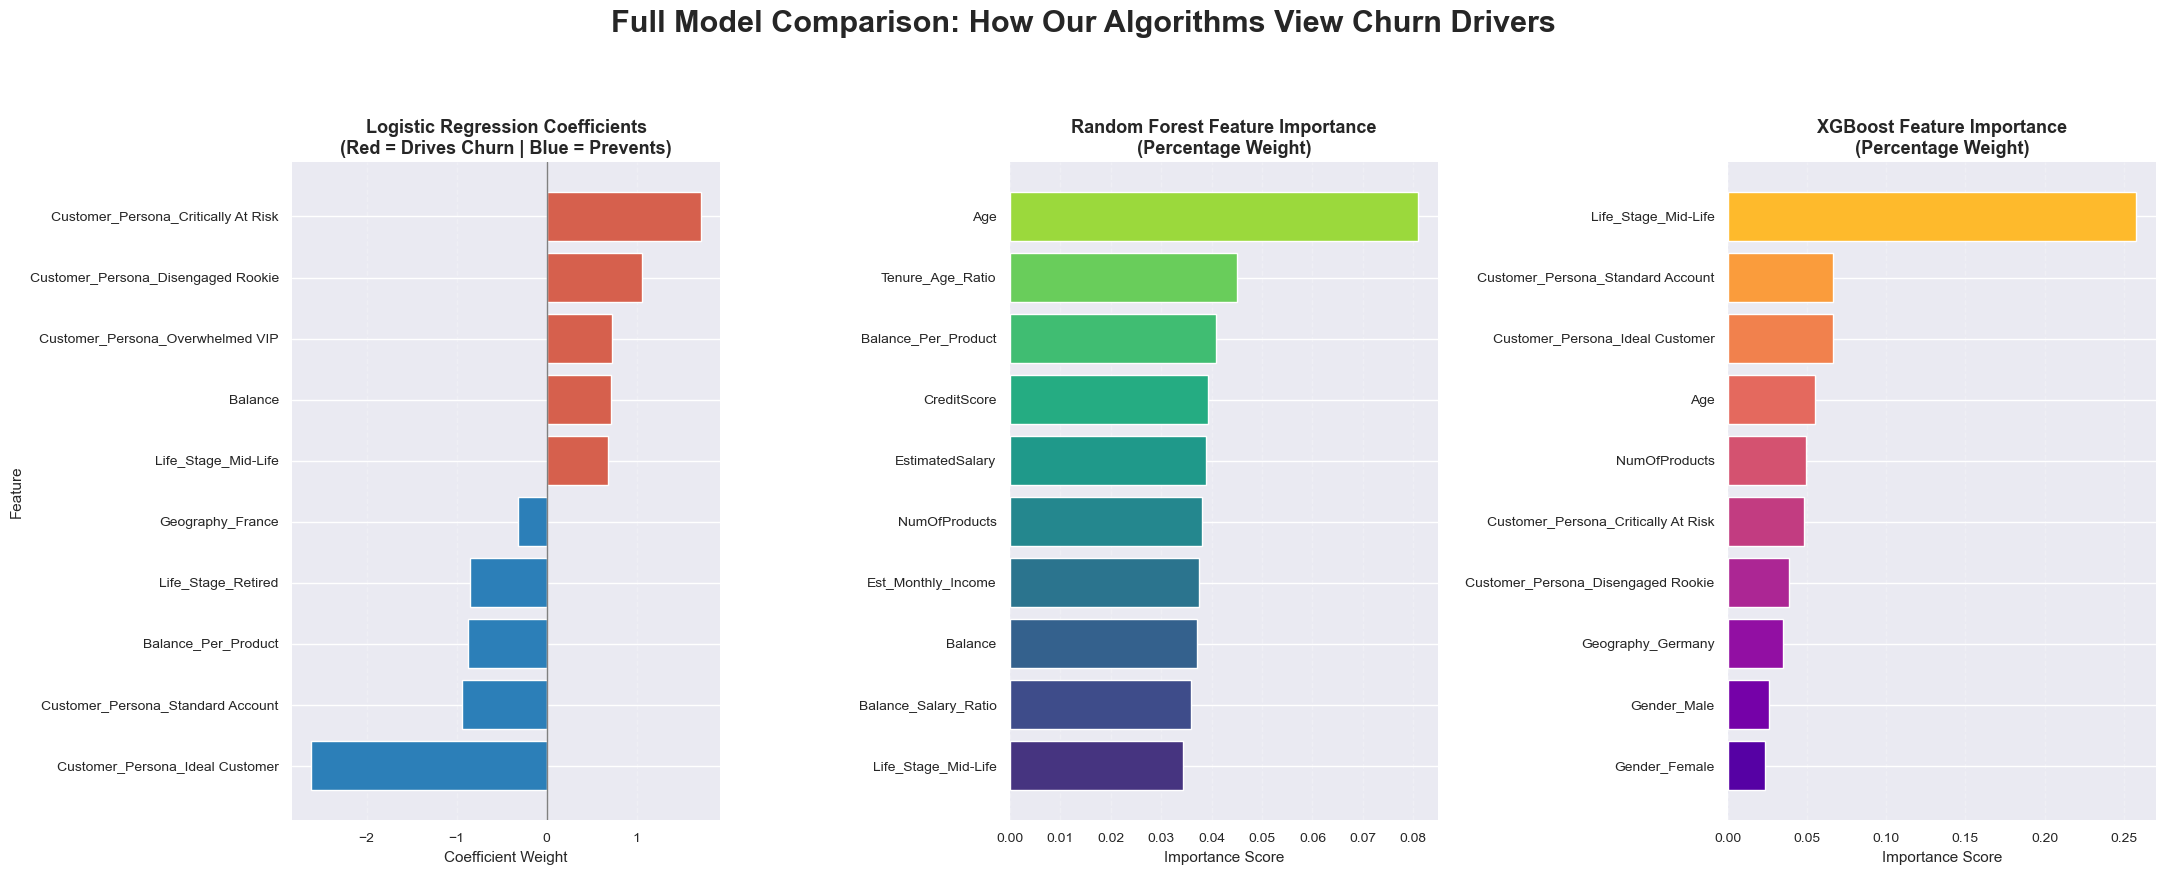

In [65]:

# ==========================================
# FINAL MODELS
# ==========================================
final_models = {
    "Logistic Regression": best_log_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_model   # or best_xgb_model if renamed
}

# ==========================================
# GET FEATURE NAMES FROM PREPROCESSOR
# ==========================================
sample_pipeline = list(final_models.values())[0]
feature_names = sample_pipeline.named_steps["preprocessor"].get_feature_names_out()

# optional cleanup of feature names
clean_feature_names = (
    pd.Series(feature_names)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .tolist()
)

# ==========================================
# EXTRACT IMPORTANCE / COEFFICIENTS
# ==========================================
# Logistic: keep signed coefficients
log_model = final_models["Logistic Regression"].named_steps["model"]
log_coef_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Value": log_model.coef_[0]
}).sort_values("Value", ascending=False)

# Random Forest: feature importance
rf_model = final_models["Random Forest"].named_steps["model"]
rf_imp_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Value": rf_model.feature_importances_
}).sort_values("Value", ascending=False)

# XGBoost: feature importance
xgb_model = final_models["XGBoost"].named_steps["model"]
xgb_imp_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Value": xgb_model.feature_importances_
}).sort_values("Value", ascending=False)

# ==========================================
# TOP 10
# ==========================================
top_log = pd.concat([
    log_coef_df.head(5),      # strongest positive
    log_coef_df.tail(5)       # strongest negative
]).sort_values("Value")

top_rf = rf_imp_df.head(10).sort_values("Value")
top_xgb = xgb_imp_df.head(10).sort_values("Value")

# ==========================================
# COLORS
# ==========================================
# Logistic: positive = red, negative = blue
log_colors = ["#2C7FB8" if v < 0 else "#D6604D" for v in top_log["Value"]]

# RF and XGB: smooth gradients
rf_colors = cm.viridis(np.linspace(0.15, 0.85, len(top_rf)))
xgb_colors = cm.plasma(np.linspace(0.15, 0.85, len(top_xgb)))

# ==========================================
# PLOT
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle(
    "Full Model Comparison: How Our Algorithms View Churn Drivers",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

# -----------------------------
# Logistic Regression
# -----------------------------
axes[0].barh(top_log["Feature"], top_log["Value"], color=log_colors, edgecolor="white")
axes[0].axvline(0, color="gray", linewidth=1)
axes[0].set_title(
    "Logistic Regression Coefficients\n(Red = Drives Churn | Blue = Prevents)",
    fontsize=13,
    fontweight="bold"
)
axes[0].set_xlabel("Coefficient Weight", fontsize=11)
axes[0].set_ylabel("Feature", fontsize=11)
axes[0].grid(axis="x", linestyle="--", alpha=0.25)

# -----------------------------
# Random Forest
# -----------------------------
axes[1].barh(top_rf["Feature"], top_rf["Value"], color=rf_colors, edgecolor="white")
axes[1].set_title(
    "Random Forest Feature Importance\n(Percentage Weight)",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_xlabel("Importance Score", fontsize=11)
axes[1].grid(axis="x", linestyle="--", alpha=0.25)

# -----------------------------
# XGBoost
# -----------------------------
axes[2].barh(top_xgb["Feature"], top_xgb["Value"], color=xgb_colors, edgecolor="white")
axes[2].set_title(
    "XGBoost Feature Importance\n(Percentage Weight)",
    fontsize=13,
    fontweight="bold"
)
axes[2].set_xlabel("Importance Score", fontsize=11)
axes[2].grid(axis="x", linestyle="--", alpha=0.25)

# ==========================================
# STYLING
# ==========================================
for ax in axes:
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

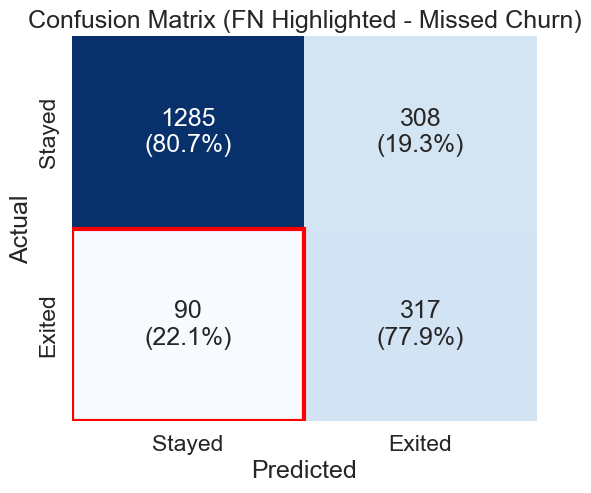

In [66]:

# Predictions
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

labels = ["Stayed", "Exited"]

# Annotation (count + %)
annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]*100:.1f}%)"

# Custom color emphasis
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)

# Highlight FN cell (bottom-left)
plt.gca().add_patch(plt.Rectangle((0,1),1,1, fill=False, edgecolor='red', lw=3))

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (FN Highlighted - Missed Churn)")

plt.show()

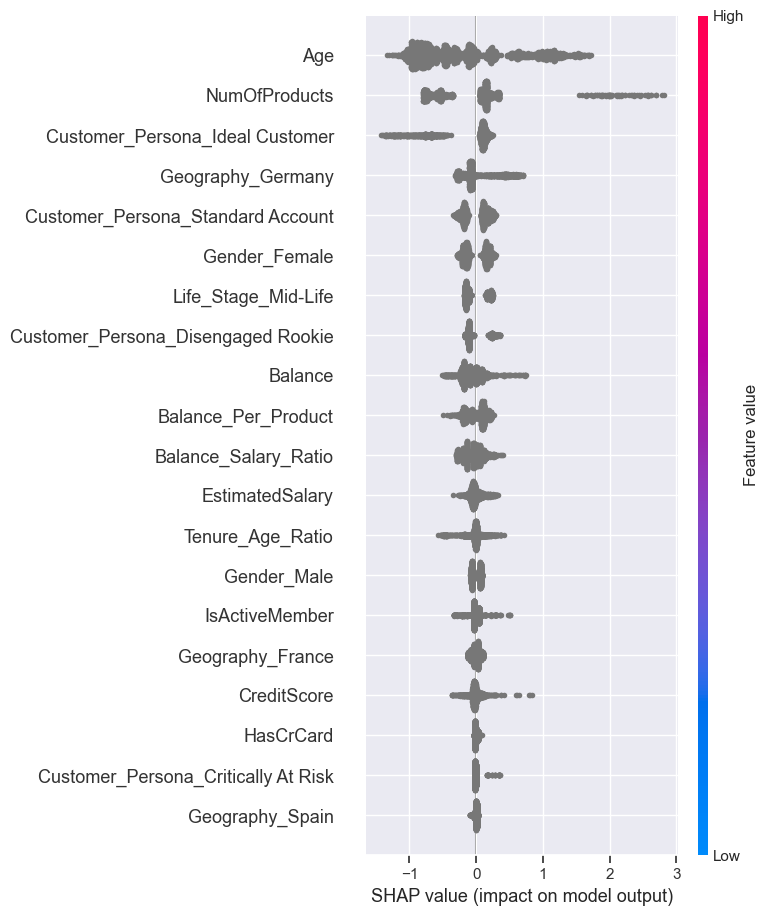

In [69]:

# Extract pipeline components
preprocessor = best_model.named_steps['preprocessor']
xgb_model = best_model.named_steps['model']

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Initialize SHAP TreeExplainer on the raw XGB model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Get feature names from preprocessor
def get_feature_names(preprocessor):
    output_features = []

    # Numeric feature names
    numeric_features = preprocessor.named_transformers_['num'].get_feature_names_out()
    output_features.extend(numeric_features)

    # OneHotEncoder feature names (categorical)
    ohe = preprocessor.named_transformers_['cat']
    cat_features = ohe.get_feature_names_out()
    output_features.extend(cat_features)

    return output_features

feature_names = get_feature_names(preprocessor)

# Plot SHAP beeswarm plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="dot", show=True)

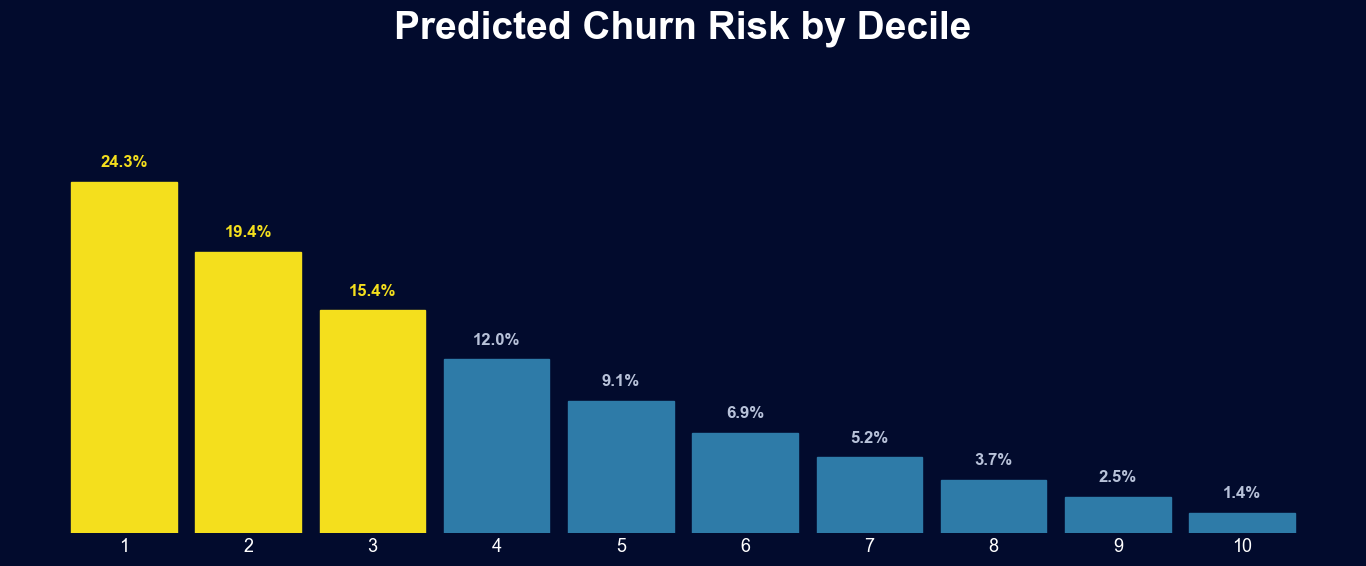

In [68]:

# ==========================================
# Generate probabilities (XGBoost)
# ==========================================
y_proba = best_model.predict_proba(X_test)[:, 1]

# ==========================================
# Build deciles
# ==========================================
df = pd.DataFrame({"churn_probability": y_proba})
df = df.sort_values("churn_probability", ascending=False).reset_index(drop=True)
df["decile"] = pd.qcut(df.index + 1, 10, labels=[1,2,3,4,5,6,7,8,9,10])

# ==========================================
# Compute share of total predicted churn risk
# ==========================================
decile_summary = df.groupby("decile", observed=False)["churn_probability"].sum().reset_index()
decile_summary["risk_pct"] = (
    decile_summary["churn_probability"] / decile_summary["churn_probability"].sum() * 100
)

# ==========================================
# Plot
# ==========================================
bg_color = "#020b2d"
bar_color = "#2e7ba8"
highlight_color = "#f4df1d"
text_color = "white"
label_color = "#b8c2d9"

fig, ax = plt.subplots(figsize=(14, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

# Highlight top 3 deciles
colors = [highlight_color if d in [1, 2, 3] else bar_color for d in decile_summary["decile"].astype(int)]

bars = ax.bar(
    decile_summary["decile"].astype(str),
    decile_summary["risk_pct"],
    color=colors,
    edgecolor=colors,
    width=0.85
)

# Add percentage labels on top
for bar, val in zip(bars, decile_summary["risk_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        color=highlight_color if bar.get_facecolor()[:3] == bars[0].get_facecolor()[:3] and False else label_color,
        fontsize=12,
        fontweight="bold"
    )

# Make labels match highlighted bars better
for i, (bar, val) in enumerate(zip(bars, decile_summary["risk_pct"])):
    is_highlight = decile_summary["decile"].astype(int).iloc[i] in [1, 2, 3]
    ax.texts[i].set_color(highlight_color if is_highlight else label_color)

# Styling
ax.set_title("Predicted Churn Risk by Decile", fontsize=28, fontweight="bold", color=text_color, pad=20)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_ylim(0, decile_summary["risk_pct"].max() + 8)

# Remove axes clutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="x", colors=text_color, labelsize=13, length=0)
ax.tick_params(axis="y", left=False, labelleft=False)
ax.grid(False)

plt.tight_layout()
plt.show()